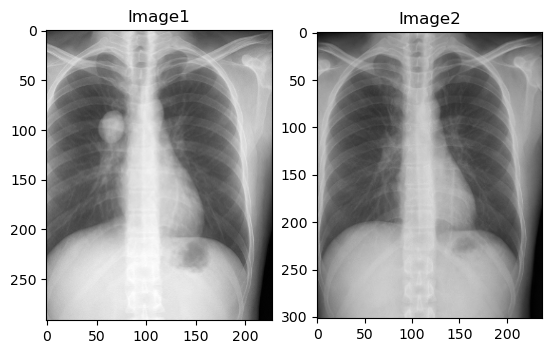

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.io import imread
# Load two grayscale medical images
img1 = imread('assets/xray1.png', as_gray=True)
img2 = imread('assets/xray2.png', as_gray=True)
plt.subplot(1,2,1); plt.imshow(img1, cmap='gray'); plt.title("Image1")
plt.subplot(1,2,2); plt.imshow(img2, cmap='gray'); plt.title("Image2")
plt.show()

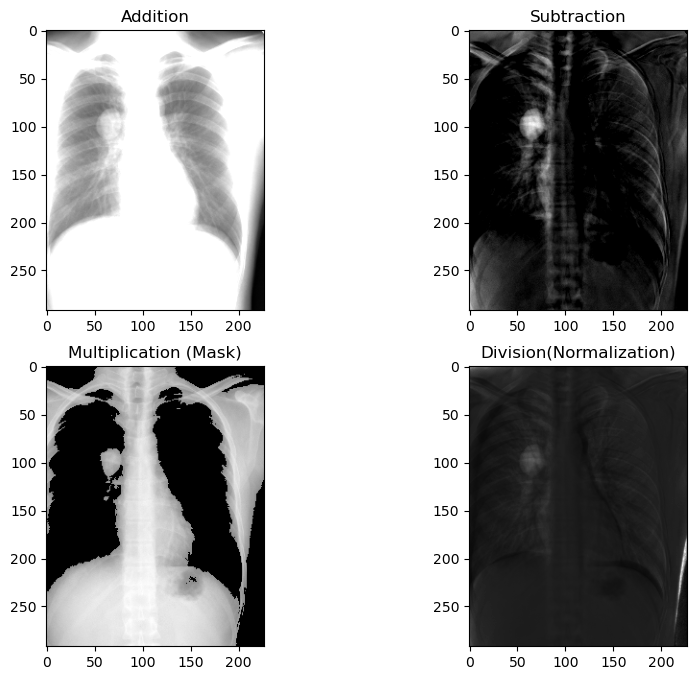

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.io import imread
from skimage.transform import resize

# Load grayscale images
img1 = imread('assets/xray1.png', as_gray=True)
img2 = imread('assets/xray2.png', as_gray=True)

# Resize img2 to match img1
img2_resized = resize(img2, img1.shape, anti_aliasing=True)
epsilon = 1e-5

# Arithmetic operations
img_add = np.clip(img1 + img2_resized , 0, 1) # Addition
img_sub = np.clip(img1 - img2_resized , 0, 1) # Subtraction
mask = (img1 > 0.5).astype(float) # Binary mask
img_mul = img1 * mask # Multiplication (ROIextraction)
img_div = img1 / (img2_resized + epsilon) # Division (Normalization)
# Show results
plt.figure(figsize=(10,8))
plt.subplot(2,2,1); plt.imshow(img_add, cmap='gray');
plt.title("Addition")
plt.subplot(2,2,2); plt.imshow(img_sub, cmap='gray');
plt.title("Subtraction")
plt.subplot(2,2,3); plt.imshow(img_mul, cmap='gray');
plt.title("Multiplication (Mask)")
plt.subplot(2,2,4); plt.imshow(img_div, cmap='gray'); plt.title("Division(Normalization)")
plt.show()

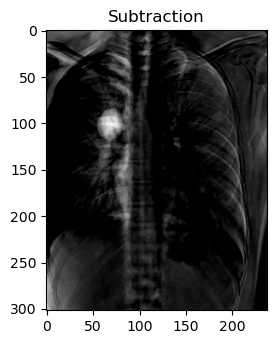

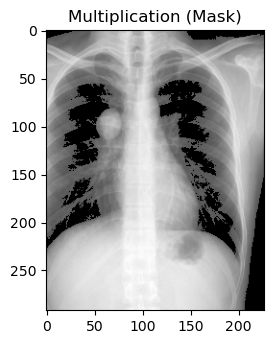

In [ ]:
#6. Exercises
#1)
img1_resized = resize(img1, img2.shape, anti_aliasing=True)
img_sub = np.clip(img1_resized - img2 , 0, 1) # Subtraction

plt.figure(figsize=(10,8))
plt.subplot(2,2,2); plt.imshow(img_sub, cmap='gray');
plt.title("Subtraction")
plt.show()

#2)
mask = (img1 > 0.3).astype(float) # Binary mask
img_mul = img1 * mask # Multiplication (ROIextraction)
plt.figure(figsize=(10,8))
plt.subplot(2,2,2); plt.imshow(img_mul, cmap='gray');
plt.title("Multiplication (Mask)")
plt.show()

In [12]:
!{sys.executable} -m pip install pydicom


Defaulting to user installation because normal site-packages is not writeable
  Using cached pydicom-3.0.1-py3-none-any.whl.metadata (9.4 kB)
Using cached pydicom-3.0.1-py3-none-any.whl (2.4 MB)


DEPRECATION: Loading egg at d:\coding\anaconda3\lib\site-packages\vboxapi-1.0-py3.11.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation.. Discussion can be found at https://github.com/pypa/pip/issues/12330
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [13]:
import pydicom
print("Pydicom version:", pydicom.__version__)


Pydicom version: 3.0.1


In [14]:
import sys
print("Python executable:", sys.executable)

!{sys.executable} -m pip show pydicom


Python executable: d:\Coding\anaconda3\python.exe
Name: pydicom
Version: 3.0.1
Summary: A pure Python package for reading and writing DICOM data
Home-page: 
Author: 
Author-email: Darcy Mason and contributors <darcymason@gmail.com>
License: 
Location: C:\Users\Asus\AppData\Roaming\Python\Python311\site-packages
Requires: 
Required-by: 


DEPRECATION: Loading egg at d:\coding\anaconda3\lib\site-packages\vboxapi-1.0-py3.11.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation.. Discussion can be found at https://github.com/pypa/pip/issues/12330


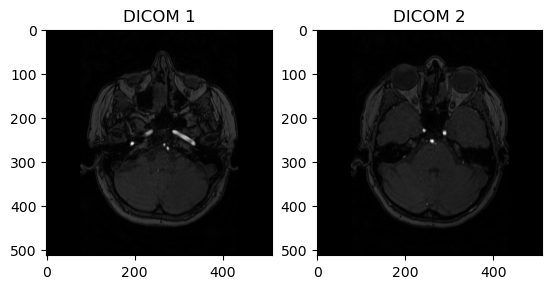

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import pydicom

# Load DICOM file
ds1 = pydicom.dcmread("assets/1-021.dcm")
ds2 = pydicom.dcmread("assets/1-035.dcm")

# Convert to numpy arrays
img1 = ds1.pixel_array.astype(float)
img2 = ds2.pixel_array.astype(float)

# Normalize (optional, so images are in 0–1 range)
img1 = (img1 - np.min(img1)) / (np.max(img1) - np.min(img1))
img2 = (img2 - np.min(img2)) / (np.max(img2) - np.min(img2))

# Show both images
plt.subplot(1,2,1); plt.imshow(img1, cmap="gray"); plt.title("DICOM 1")
plt.subplot(1,2,2); plt.imshow(img2, cmap="gray"); plt.title("DICOM 2")
plt.show()


4. Discuss a clinical scenario where subtraction imaging is very useful (hint: follow-up
scans for tumors or fractures).

In a medical case where a patient with brain tumor is diagnoes every few months
The baseline scan or before treatment shows the size and shape of the tumor.
Then a follow-up scan or after treatment/surgery is taken to monitor changes.
By applying substraction imaging(follow-up - baseline), we can:
    - Highlight only the changes either growth, shrink or other that happened to the tumor
    - Remove irrelevant background tissue, so the tumor progression is clearer
    - Detect even small changes that might not be obvious by visual inspection alone   

7. Questions for Students
    1. Which operation is most suitable for detecting temporal changes in follow-up medical scans?
    2. Why do we need to add a small value (epsilon) in the division operation?
    3. How can multiplication with a mask be used to focus on a tumor or organ?
    4. What is the main difference in visual effect between substraction and division?

    ------------ANSWERS------------

    1. Substraction, like as I said before, substraction is focuses on highlighting the differences between two images taken at different times
    2. To avoid division by zero, like we add a tiny constant value so the result of the division would not lead to errors or infinite values
    3. To isolate a ROI, because multiplication is focuses with a binary mask which the values are between 0 to 1. We can easily analyze or visualize only the tumor or organ, ignoring surrounding tissue. 
    4. Addition and substraction have different purposes, additions makes image brighter and enchance overall constrast, since pixel values are combined. Meanwhile substraction is more to highlight differences between two images, useful for detection changes like lesions, fractures, or tumor progression